In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import torchvision
import torchvision.transforms as transforms
from torchvision.utils import make_grid

import matplotlib.pyplot as plt
import numpy as np

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


MNIST Dataset

In [3]:
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

test_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    transform=transform,
    download=True
)

batch_size = 128

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 489kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.67MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.8MB/s]


VAE Modeli — latent_dim = 2

In [4]:
class VAE(nn.Module):
    def __init__(self, latent_dim=2):
        super(VAE, self).__init__()

        self.latent_dim = latent_dim

        # Encoder
        self.fc1 = nn.Linear(28 * 28, 512)
        self.fc2 = nn.Linear(512, 256)

        # Latent distribution
        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)

        # Decoder
        self.fc3 = nn.Linear(latent_dim, 256)
        self.fc4 = nn.Linear(256, 512)
        self.fc5 = nn.Linear(512, 28 * 28)

    def encode(self, x):
        x = x.view(x.size(0), -1)

        h = F.relu(self.fc1(x))
        h = F.relu(self.fc2(h))

        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)

        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        epsilon = torch.randn_like(std)
        z = mu + std * epsilon
        return z

    def decode(self, z):
        h = F.relu(self.fc3(z))
        h = F.relu(self.fc4(h))
        x_hat = torch.sigmoid(self.fc5(h))

        x_hat = x_hat.view(z.size(0), 1, 28, 28)
        return x_hat

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z)

        return x_hat, mu, logvar

Loss Function

VAE’de loss iki parçadan oluşuyor:

Reconstruction Loss: Görüntü ne kadar iyi geri üretildi?
KL Loss: Latent space normal dağılıma ne kadar yakın?



In [5]:
def vae_loss(reconstructed, original, mu, logvar):
    # Reconstruction loss
    bce = F.binary_cross_entropy(
        reconstructed,
        original,
        reduction="sum"
    )

    # KL divergence
    kld = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    total_loss = bce + kld

    return total_loss, bce, kld

Model ve Optimizer

In [6]:
latent_dim = 2

model = VAE(latent_dim=latent_dim).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 30

train_losses = []
reconstruction_losses = []
kl_losses = []

Training Loop

In [7]:
for epoch in range(num_epochs):
    model.train()

    total_loss = 0
    total_bce = 0
    total_kld = 0

    for images, _ in train_loader:
        images = images.to(device)

        reconstructed, mu, logvar = model(images)

        loss, bce, kld = vae_loss(reconstructed, images, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_bce += bce.item()
        total_kld += kld.item()

    avg_loss = total_loss / len(train_dataset)
    avg_bce = total_bce / len(train_dataset)
    avg_kld = total_kld / len(train_dataset)

    train_losses.append(avg_loss)
    reconstruction_losses.append(avg_bce)
    kl_losses.append(avg_kld)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Total Loss: {avg_loss:.4f} | "
        f"Reconstruction Loss: {avg_bce:.4f} | "
        f"KL Loss: {avg_kld:.4f}"
    )

Epoch [1/30] Total Loss: 181.6635 | Reconstruction Loss: 177.5563 | KL Loss: 4.1072
Epoch [2/30] Total Loss: 159.0155 | Reconstruction Loss: 153.5592 | KL Loss: 5.4564
Epoch [3/30] Total Loss: 153.9130 | Reconstruction Loss: 148.1267 | KL Loss: 5.7863
Epoch [4/30] Total Loss: 150.7221 | Reconstruction Loss: 144.7363 | KL Loss: 5.9858
Epoch [5/30] Total Loss: 148.5050 | Reconstruction Loss: 142.3751 | KL Loss: 6.1299
Epoch [6/30] Total Loss: 147.0083 | Reconstruction Loss: 140.7780 | KL Loss: 6.2303
Epoch [7/30] Total Loss: 145.7240 | Reconstruction Loss: 139.4348 | KL Loss: 6.2892
Epoch [8/30] Total Loss: 144.8841 | Reconstruction Loss: 138.5400 | KL Loss: 6.3441
Epoch [9/30] Total Loss: 144.2077 | Reconstruction Loss: 137.7974 | KL Loss: 6.4103
Epoch [10/30] Total Loss: 143.4113 | Reconstruction Loss: 136.9603 | KL Loss: 6.4509
Epoch [11/30] Total Loss: 142.7666 | Reconstruction Loss: 136.2636 | KL Loss: 6.5030
Epoch [12/30] Total Loss: 142.3129 | Reconstruction Loss: 135.7664 | KL Lo

Loss Grafiği

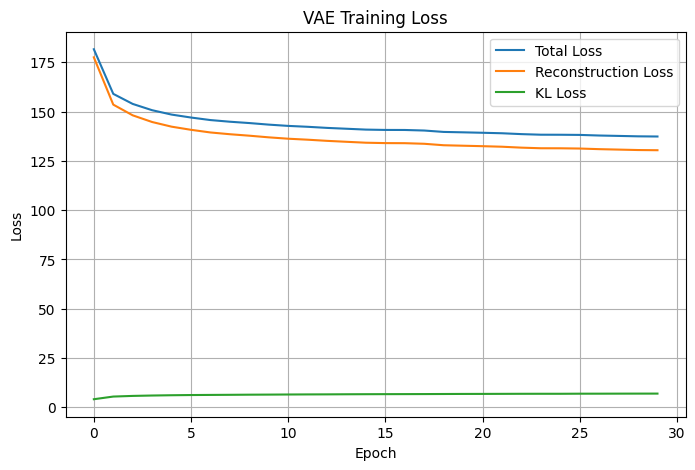

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Total Loss")
plt.plot(reconstruction_losses, label="Reconstruction Loss")
plt.plot(kl_losses, label="KL Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Training Loss")
plt.legend()
plt.grid(True)
plt.show()

Görsel Gösterme Fonksiyonu

In [9]:
def show_images(images, title, nrow=8):
    images = images.detach().cpu()

    grid = make_grid(images, nrow=nrow, padding=2)
    np_grid = grid.permute(1, 2, 0).numpy()

    plt.figure(figsize=(8, 8))
    plt.imshow(np_grid, cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()

Dataset’ten Gerçek MNIST Görselleri

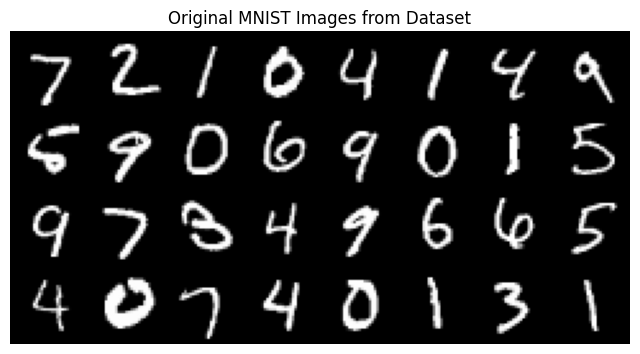

In [10]:
model.eval()

images, labels = next(iter(test_loader))
images = images.to(device)

show_images(images[:32], "Original MNIST Images from Dataset", nrow=8)

Original vs Reconstructed Görseller

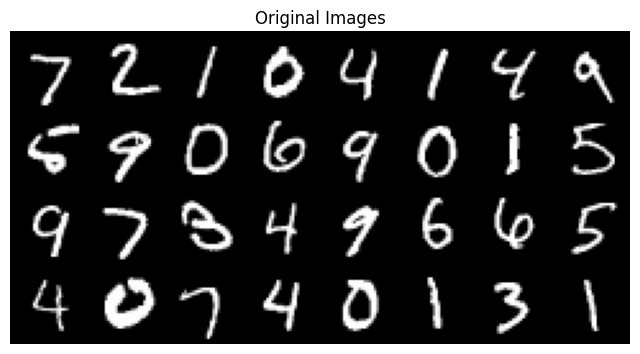

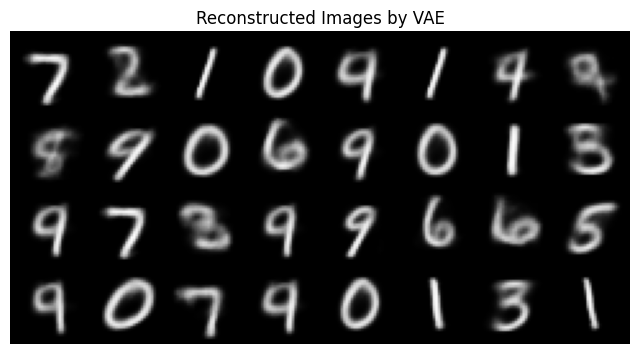

In [11]:
model.eval()

with torch.no_grad():
    images, labels = next(iter(test_loader))
    images = images.to(device)

    reconstructed, mu, logvar = model(images)

show_images(images[:32], "Original Images", nrow=8)
show_images(reconstructed[:32], "Reconstructed Images by VAE", nrow=8)

Random Generated Görseller

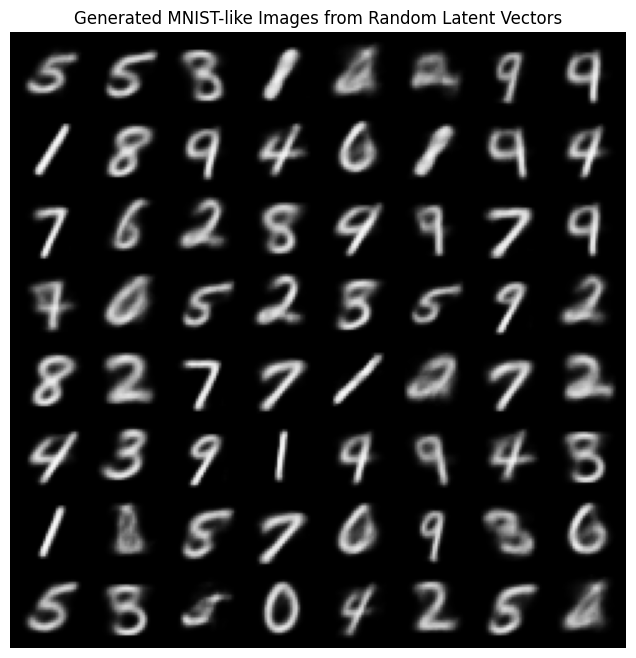

In [12]:
model.eval()

with torch.no_grad():
    z = torch.randn(64, latent_dim).to(device)
    generated = model.decode(z)

show_images(generated, "Generated MNIST-like Images from Random Latent Vectors", nrow=8)

2D Latent Space Manifold Görseli

Burada latent space’te düzenli bir grid oluşturuyoruz. Her noktayı decoder’dan geçiriyoruz.

In [13]:
def plot_latent_manifold(model, n=25, digit_size=28, scale=3.0):
    model.eval()

    figure = np.zeros((digit_size * n, digit_size * n))

    grid_x = np.linspace(-scale, scale, n)
    grid_y = np.linspace(scale, -scale, n)

    with torch.no_grad():
        for i, yi in enumerate(grid_y):
            for j, xi in enumerate(grid_x):
                z = torch.tensor([[xi, yi]], dtype=torch.float32).to(device)

                generated = model.decode(z)
                digit = generated.view(digit_size, digit_size).cpu().numpy()

                figure[
                    i * digit_size : (i + 1) * digit_size,
                    j * digit_size : (j + 1) * digit_size
                ] = digit

    plt.figure(figsize=(12, 12))
    plt.imshow(figure, cmap="gray")
    plt.title("2D VAE Latent Space Manifold")
    plt.axis("off")
    plt.show()

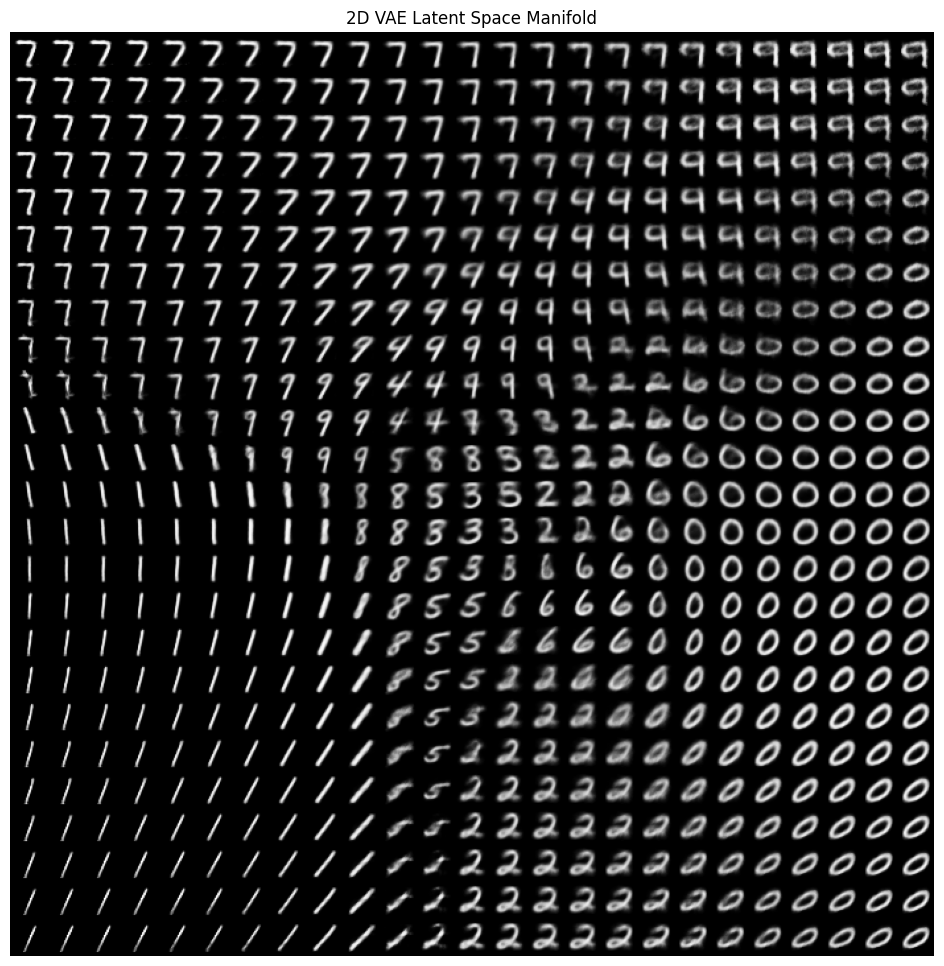

In [14]:
plot_latent_manifold(model, n=25, scale=3.0)

Bonus: Latent Space Scatter Plot

Test setindeki rakamların latent space’te nereye yerleştiğini gösterir.

In [15]:
def plot_latent_scatter(model, data_loader, max_batches=100):
    model.eval()

    all_mu = []
    all_labels = []

    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(data_loader):
            images = images.to(device)

            mu, logvar = model.encode(images)

            all_mu.append(mu.cpu())
            all_labels.append(labels)

            if batch_idx >= max_batches:
                break

    all_mu = torch.cat(all_mu, dim=0).numpy()
    all_labels = torch.cat(all_labels, dim=0).numpy()

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(
        all_mu[:, 0],
        all_mu[:, 1],
        c=all_labels,
        cmap="tab10",
        s=8,
        alpha=0.7
    )

    plt.colorbar(scatter, label="Digit Label")
    plt.xlabel("Latent Dimension 1")
    plt.ylabel("Latent Dimension 2")
    plt.title("MNIST Digits in 2D Latent Space")
    plt.grid(True)
    plt.show()

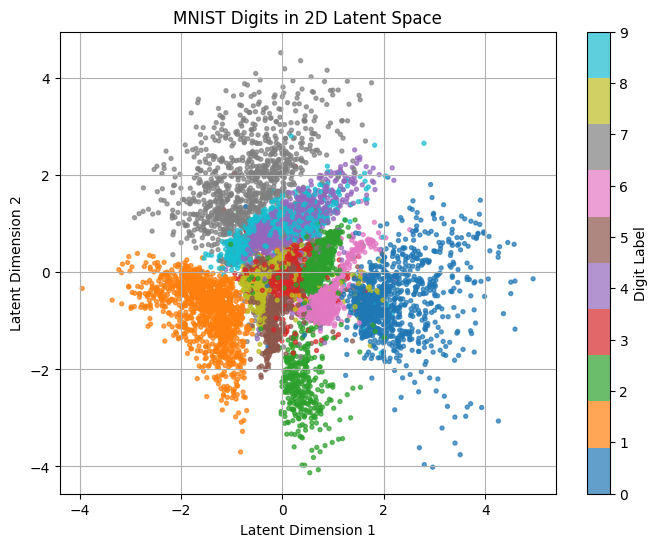

In [16]:
plot_latent_scatter(model, test_loader)